# Organizing all the data in a dictionary

In [240]:
dict_countries = {
    "Spanish La Liga": "SP1", "Spanish Segunda Division": "SP2", "German Bundes liga": "D1", "English Premier League": "E0", "English League 1": "E2"
}

In [241]:
# getting dictionary element
dict_countries["Spanish La Liga"]

'SP1'

In [2]:
import pandas as pd
root = "https://football-data.co.uk/mmz4281/"
leagues = ["E0", "E1", "E2", "E3", "EC"]
data_dict = {}

for league in leagues:
    for season in range(21, 25):
        season_str = str(season) + str(season + 1)
        url = f'{root}{season_str}/{league}.csv'
        key = f'{league}_{season_str}'
        print(f"Downloading {url}")

        try:
            df = pd.read_csv(url, encoding="UTF-8")
        except UnicodeDecodeError:
            try:
                df = pd.read_csv(url, encoding="ISO-8859-1")
            except Exception as e:
                print(f"Failed to decode {league} {season_str}: error: {e}")
                continue

        except Exception as e:
            print(f"Failed to load {league} {season_str}: error: {e}")
            continue
        df["League"] = league
        df["Season"] = season_str
        data_dict[key] = df



{'E0_2122':     Div        Date   Time        HomeTeam        AwayTeam  FTHG  FTAG FTR  \
 0    E0  13/08/2021  20:00       Brentford         Arsenal     2     0   H   
 1    E0  14/08/2021  12:30      Man United           Leeds     5     1   H   
 2    E0  14/08/2021  15:00         Burnley        Brighton     1     2   A   
 3    E0  14/08/2021  15:00         Chelsea  Crystal Palace     3     0   H   
 4    E0  14/08/2021  15:00         Everton     Southampton     3     1   H   
 ..   ..         ...    ...             ...             ...   ...   ...  ..   
 375  E0  22/05/2022  16:00  Crystal Palace      Man United     1     0   H   
 376  E0  22/05/2022  16:00       Leicester     Southampton     4     1   H   
 377  E0  22/05/2022  16:00       Liverpool          Wolves     3     1   H   
 378  E0  22/05/2022  16:00        Man City     Aston Villa     3     2   H   
 379  E0  22/05/2022  16:00         Norwich       Tottenham     0     5   A   
 
      HTHG  HTAG  ... B365CAHH B365CAHA

In [243]:
epl_2324 = pd.concat([data_dict[k] for k in ["E0_2324", "E0_2425"]], ignore_index=True)

epl_2324

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755,E0,25/05/2025,16:00,Newcastle,Everton,0,1,A,0,0,...,1.30,6.11,10.20,1.27,7.0,13.00,1.50,2.94,1.93,2.05
756,E0,25/05/2025,16:00,Nott'm Forest,Chelsea,0,1,A,0,0,...,3.50,3.86,2.06,3.55,3.9,2.14,1.76,2.28,1.86,2.14
757,E0,25/05/2025,16:00,Southampton,Arsenal,1,2,A,0,1,...,12.20,6.11,1.28,13.00,6.8,1.28,1.45,3.15,2.06,1.89
758,E0,25/05/2025,16:00,Tottenham,Brighton,1,4,A,1,0,...,3.63,4.12,1.95,3.95,4.2,1.93,1.51,2.92,2.06,1.93


In [244]:
filtered_dict = {}
for key, df in data_dict.items():
    required_fields = ["HomeTeam", "AwayTeam", "FTHG", "FTAG"]
    if all(col in df.columns for col in required_fields):
        extra_cols = [col for col in ["League", "Season"] if col in df.columns]
        filtered_dict[key] = df[required_fields + extra_cols]

merged_df = pd.concat(filtered_dict, ignore_index=True)

Working with a specific League or Season

In [245]:
# e0_data = [<what_to_include> for <key>, <value> in <dict>.items() if <condition>] ---> Comprehension pattern
e0_data = [df for key, df in data_dict.items() if key.startswith("E0_")]
e0_data


[    Div        Date   Time        HomeTeam        AwayTeam  FTHG  FTAG FTR  \
 0    E0  13/08/2021  20:00       Brentford         Arsenal     2     0   H   
 1    E0  14/08/2021  12:30      Man United           Leeds     5     1   H   
 2    E0  14/08/2021  15:00         Burnley        Brighton     1     2   A   
 3    E0  14/08/2021  15:00         Chelsea  Crystal Palace     3     0   H   
 4    E0  14/08/2021  15:00         Everton     Southampton     3     1   H   
 ..   ..         ...    ...             ...             ...   ...   ...  ..   
 375  E0  22/05/2022  16:00  Crystal Palace      Man United     1     0   H   
 376  E0  22/05/2022  16:00       Leicester     Southampton     4     1   H   
 377  E0  22/05/2022  16:00       Liverpool          Wolves     3     1   H   
 378  E0  22/05/2022  16:00        Man City     Aston Villa     3     2   H   
 379  E0  22/05/2022  16:00         Norwich       Tottenham     0     5   A   
 
      HTHG  HTAG  ... B365CAHH B365CAHA  PCAHH  PC

In [246]:
list_dict =  {"name": "Hudson", "price": 20}
list_data = [data for key, data in list_dict.items()]
filtered = merged_df[merged_df["League"] == "E0"]
filtered

,HomeTeam,AwayTeam,FTHG,FTAG,League,Season
0,Brentford,Arsenal,2,0,E0,2122
1,Man United,Leeds,5,1,E0,2122
2,Burnley,Brighton,1,2,E0,2122
3,Chelsea,Crystal Palace,3,0,E0,2122
4,Everton,Southampton,3,1,E0,2122
...,...,...,...,...,...,...
1515,Newcastle,Everton,0,1,E0,2425
1516,Nott'm Forest,Chelsea,0,1,E0,2425
1517,Southampton,Arsenal,1,2,E0,2425
1518,Tottenham,Brighton,1,4,E0,2425


In [247]:
import numpy as np
import pandas as pd

# Get the average
avg_home_goals = np.mean(merged_df["FTHG"])
print(f"{avg_home_goals: .2f}")

high_scoring_goals = merged_df[merged_df["FTHG"] > avg_home_goals]

# Sorting high scoring goals
sorted_high_scores = high_scoring_goals.sort_values(by='FTHG', ascending=False)

# Assigning High or normal base on the scores
merged_df["High Scoring"] = np.where(merged_df["FTHG"] > avg_home_goals, "High", "Normal")
merged_df

 1.47


,HomeTeam,AwayTeam,FTHG,FTAG,League,Season,High Scoring
0,Brentford,Arsenal,2,0,E0,2122,High
1,Man United,Leeds,5,1,E0,2122,High
2,Burnley,Brighton,1,2,E0,2122,Normal
3,Chelsea,Crystal Palace,3,0,E0,2122,High
4,Everton,Southampton,3,1,E0,2122,High
...,...,...,...,...,...,...,...
10301,Maidenhead,Boston Utd,3,0,EC,2425,High
10302,Oldham,Ebbsfleet,2,0,EC,2425,High
10303,Solihull,Dag and Red,1,1,EC,2425,Normal
10304,Sutton,Woking,1,1,EC,2425,Normal


In [248]:
merged_df["High Scoring"].value_counts()


High Scoring
Normal    5920
High      4386
Name: count, dtype: int64

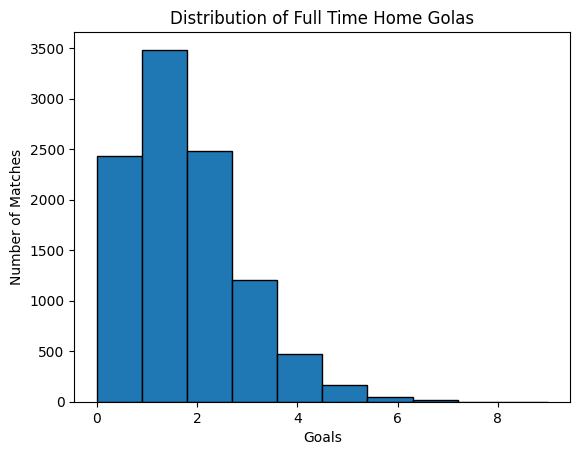

In [249]:
import matplotlib.pyplot as plt

plt.hist(merged_df["FTHG"], bins=10, edgecolor="black")
plt.title("Distribution of Full Time Home Golas")
plt.xlabel('Goals')
plt.ylabel('Number of Matches')
plt.show()

In [250]:
check_loss_draw = np.where(merged_df["FTHG"] == merged_df["FTAG"], "Draw", "Loss")
merged_df["Match Result"] = np.where(merged_df["FTHG"] > merged_df["FTAG"], "Win", check_loss_draw)

arsenal_losses = merged_df[(merged_df["HomeTeam"] == "Brentford") & (merged_df["Match Result"] == "Loss")]
arsenal_losses

,HomeTeam,AwayTeam,FTHG,FTAG,League,Season,High Scoring,Match Result
32,Brentford,Brighton,0,1,E0,2122,Normal,Loss
76,Brentford,Chelsea,0,1,E0,2122,Normal,Loss
87,Brentford,Leicester,1,2,E0,2122,Normal,Loss
102,Brentford,Norwich,1,2,E0,2122,Normal,Loss
181,Brentford,Man City,0,1,E0,2122,Normal,Loss
203,Brentford,Man United,1,3,E0,2122,Normal,Loss
206,Brentford,Wolves,1,2,E0,2122,Normal,Loss
250,Brentford,Newcastle,0,2,E0,2122,Normal,Loss
371,Brentford,Leeds,1,2,E0,2122,Normal,Loss
445,Brentford,Arsenal,0,3,E0,2223,Normal,Loss


Using Select np.select()

In [251]:
merged_df["Total Goals"] = merged_df["FTHG"] + merged_df["FTAG"]

# Create conditions - List of boolean
conditions = [merged_df["Total Goals"] >= 5, merged_df["Total Goals"] <= 1 ]

# Defining the labels (choices)
choices = ["Goal Fest", "Tight Game"]

# np.select(conditions, choices, default=default Value ~ None)
merged_df["Match Type"] = np.select(conditions, choices, default="Average")

merged_df[["HomeTeam", "AwayTeam", "FTHG", "FTAG", "Total Goals", "Match Type"]]

,HomeTeam,AwayTeam,FTHG,FTAG,Total Goals,Match Type
0,Brentford,Arsenal,2,0,2,Average
1,Man United,Leeds,5,1,6,Goal Fest
2,Burnley,Brighton,1,2,3,Average
3,Chelsea,Crystal Palace,3,0,3,Average
4,Everton,Southampton,3,1,4,Average
...,...,...,...,...,...,...
10301,Maidenhead,Boston Utd,3,0,3,Average
10302,Oldham,Ebbsfleet,2,0,2,Average
10303,Solihull,Dag and Red,1,1,2,Average
10304,Sutton,Woking,1,1,2,Average


## Filtering Dataframes based on two or more conditions

In [252]:
thrilling_matches = merged_df[(merged_df["Season"] == "2324") & (merged_df["FTHG"] >= 2) & (merged_df["FTAG"] >=1)]
# Adding total goals columns


### Label Match Outcome from Home Team's view

In [253]:
conditions = [
    merged_df["FTHG"] > merged_df["FTAG"],
    merged_df["FTHG"] == merged_df["FTAG"],
    merged_df["FTHG"] < merged_df["FTAG"],
]

choices_label = ["Win", "Draw", "Loss"]
merged_df["Outcome"] = np.select(conditions, choices_label, default=None)
merged_df

,HomeTeam,AwayTeam,FTHG,FTAG,League,Season,High Scoring,Match Result,Total Goals,Match Type,Outcome
0,Brentford,Arsenal,2,0,E0,2122,High,Win,2,Average,Win
1,Man United,Leeds,5,1,E0,2122,High,Win,6,Goal Fest,Win
2,Burnley,Brighton,1,2,E0,2122,Normal,Loss,3,Average,Loss
3,Chelsea,Crystal Palace,3,0,E0,2122,High,Win,3,Average,Win
4,Everton,Southampton,3,1,E0,2122,High,Win,4,Average,Win
...,...,...,...,...,...,...,...,...,...,...,...
10301,Maidenhead,Boston Utd,3,0,EC,2425,High,Win,3,Average,Win
10302,Oldham,Ebbsfleet,2,0,EC,2425,High,Win,2,Average,Win
10303,Solihull,Dag and Red,1,1,EC,2425,Normal,Draw,2,Average,Draw
10304,Sutton,Woking,1,1,EC,2425,Normal,Draw,2,Average,Draw


## Filtering DataFrames Based on Multiple Conditions (Advanced)

In [254]:
# Matches where home team won AND total goals > 5

filtered_2 = merged_df[(merged_df["FTHG"] > merged_df["FTAG"]) & (merged_df['Total Goals'] >= 5) ]


In [255]:
# Matches "where" home team is Arsenal or Man City And Match ended in draw
filtered_3 = merged_df[((merged_df["HomeTeam"] == "Arsenal") | (merged_df["HomeTeam"] == "Man City")) & (merged_df["Match Result"] == "Draw") ]
filtered_3

,HomeTeam,AwayTeam,FTHG,FTAG,League,Season,High Scoring,Match Result,Total Goals,Match Type,Outcome
44,Man City,Southampton,0,0,E0,2122,Normal,Draw,0,Tight Game,Draw
79,Arsenal,Crystal Palace,2,2,E0,2122,High,Draw,4,Average,Draw
210,Arsenal,Burnley,0,0,E0,2122,Normal,Draw,0,Tight Game,Draw
308,Man City,Liverpool,2,2,E0,2122,High,Draw,4,Average,Draw
541,Man City,Everton,1,1,E0,2223,Normal,Draw,2,Average,Draw
547,Arsenal,Newcastle,0,0,E0,2223,Normal,Draw,0,Tight Game,Draw
591,Arsenal,Brentford,1,1,E0,2223,Normal,Draw,2,Average,Draw
686,Arsenal,Southampton,3,3,E0,2223,High,Draw,6,Goal Fest,Draw
781,Arsenal,Fulham,2,2,E0,2324,High,Draw,4,Average,Draw
814,Arsenal,Tottenham,2,2,E0,2324,High,Draw,4,Average,Draw


In [256]:
# Not involving Chelsea as either home or away Team
filtered_4 = merged_df[(merged_df["HomeTeam"] != "Chelsea") & (merged_df["AwayTeam"] != "Chelsea") ]
filtered_4

,HomeTeam,AwayTeam,FTHG,FTAG,League,Season,High Scoring,Match Result,Total Goals,Match Type,Outcome
0,Brentford,Arsenal,2,0,E0,2122,High,Win,2,Average,Win
1,Man United,Leeds,5,1,E0,2122,High,Win,6,Goal Fest,Win
2,Burnley,Brighton,1,2,E0,2122,Normal,Loss,3,Average,Loss
4,Everton,Southampton,3,1,E0,2122,High,Win,4,Average,Win
5,Leicester,Wolves,1,0,E0,2122,Normal,Win,1,Tight Game,Win
...,...,...,...,...,...,...,...,...,...,...,...
10301,Maidenhead,Boston Utd,3,0,EC,2425,High,Win,3,Average,Win
10302,Oldham,Ebbsfleet,2,0,EC,2425,High,Win,2,Average,Win
10303,Solihull,Dag and Red,1,1,EC,2425,Normal,Draw,2,Average,Draw
10304,Sutton,Woking,1,1,EC,2425,Normal,Draw,2,Average,Draw


## Complex logic using isin() with lists

In [257]:
top_teams = ["Arsenal", "Man City", "Liverpool"]
filtered = merged_df[(merged_df["HomeTeam"].isin(top_teams)) & (merged_df["FTHG"] >=2)]
filtered

,HomeTeam,AwayTeam,FTHG,FTAG,League,Season,High Scoring,Match Result,Total Goals,Match Type,Outcome
10,Liverpool,Burnley,2,0,E0,2122,High,Win,2,Average,Win
14,Man City,Norwich,5,0,E0,2122,High,Win,5,Goal Fest,Win
20,Man City,Arsenal,5,0,E0,2122,High,Win,5,Goal Fest,Win
43,Liverpool,Crystal Palace,3,0,E0,2122,High,Win,3,Average,Win
58,Arsenal,Tottenham,3,1,E0,2122,High,Win,4,Average,Win
...,...,...,...,...,...,...,...,...,...,...,...
1470,Man City,Aston Villa,2,1,E0,2425,High,Win,3,Average,Win
1471,Arsenal,Crystal Palace,2,2,E0,2425,High,Draw,4,Average,Draw
1478,Liverpool,Tottenham,5,1,E0,2425,High,Win,6,Goal Fest,Win
1499,Liverpool,Arsenal,2,2,E0,2425,High,Draw,4,Average,Draw


## Complex logic using query() with lists

In [258]:
filtered = merged_df.query("Season == '2324' and FTHG >=3 and FTAG >=2 ")


In [259]:
data = {
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'age': [25, 30, 45, 11, 23],
    'city': ['NYC', 'LA', 'NYC', 'Chicago', 'Washington']
}

data_pd = pd.DataFrame(data)
data_pd


# Query people older than 30
older_than_30 = data_pd.query('age > 30')
older_than_30

data_pd.query('city == "Chicago" and age < 30')

# Using variable in query by using "@"
min_age = 24
data_pd.query("age > @min_age")

,name,age,city
0,Alice,25,NYC
1,Bob,30,LA
2,Charlie,45,NYC


## Filtering by .loc[]

In [260]:
# Retrieving a specific role base on their index label
merged_df.loc[1]

HomeTeam        Man United
AwayTeam             Leeds
FTHG                     5
FTAG                     1
League                  E0
Season                2122
High Scoring          High
Match Result           Win
Total Goals              6
Match Type       Goal Fest
Outcome                Win
Name: 1, dtype: object

In [261]:
merged_df.loc[1, "FTHG"]

np.int64(5)

# Challenge

In [262]:
home_dominations = merged_df[(merged_df["Season"] == "2324") & (merged_df["FTHG"] >= 3) & (merged_df["FTAG"] <= 1) & ((merged_df["FTHG"] - merged_df["FTAG"] ) >= 2) ]

# Adding a goal difference
merged_df

,HomeTeam,AwayTeam,FTHG,FTAG,League,Season,High Scoring,Match Result,Total Goals,Match Type,Outcome
0,Brentford,Arsenal,2,0,E0,2122,High,Win,2,Average,Win
1,Man United,Leeds,5,1,E0,2122,High,Win,6,Goal Fest,Win
2,Burnley,Brighton,1,2,E0,2122,Normal,Loss,3,Average,Loss
3,Chelsea,Crystal Palace,3,0,E0,2122,High,Win,3,Average,Win
4,Everton,Southampton,3,1,E0,2122,High,Win,4,Average,Win
...,...,...,...,...,...,...,...,...,...,...,...
10301,Maidenhead,Boston Utd,3,0,EC,2425,High,Win,3,Average,Win
10302,Oldham,Ebbsfleet,2,0,EC,2425,High,Win,2,Average,Win
10303,Solihull,Dag and Red,1,1,EC,2425,Normal,Draw,2,Average,Draw
10304,Sutton,Woking,1,1,EC,2425,Normal,Draw,2,Average,Draw


### Finding Duplicate Rows with duplicated()

In [263]:
merged_df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
10301    False
10302    False
10303    False
10304    False
10305    False
Length: 10306, dtype: bool

In [21]:
import pandas as pd

laptops_df = pd.read_csv("./laptop.csv", quotechar='"')
laptops_df["Price Value"] = laptops_df["price"].replace({
    "₹": "", ",": ""
}, regex=True).astype(float)

Finding Cheapest and Most Expensive Laptops with Duplicates

In [5]:
min_price = laptops_df["Price Value"].min()
max_price = laptops_df["Price Value"].max()

# Finding with duplicates
duplicates = laptops_df[laptops_df.duplicated(keep=False)]

# Checking which ones are also cheapes
cheapest_with_duplicates = duplicates[duplicates["Price Value"] == min_price]
expensive_with_duplicates = duplicates[duplicates["Price Value"] == max_price]



# Finding the cheapest and most expensive laptops
cheapest_laptop = laptops_df[laptops_df["Price Value"] == min_price]
most_expensive = laptops_df[laptops_df["Price Value"] == max_price]



Removing Duplicate Rows with drop_duplicates()

In [6]:
unique_laptops = laptops_df.drop_duplicates()
unique_laptops

,name,price,spec_score,votes,user_rating,os,utility,thickness,weight,warranty,...,no_cores,caches,graphics_card,rom_memory,internal_memory,port_connection,wireless_connection,usb_ports,hardware_features,Price Value
0,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,"₹49,800",70.0,97 votes,4.3,OS: Windows 11,Utility: Gaming,Thickness: 23.5 mmThick,2.29 kgHeavy,1 Year Warranty,...,"Hexa Core, 12 Threads",16 MB Cache,"4 GB, AMD Radeon RX 6500M GraphicsLargest",8 GB DDR4 RAMAverage,512 GB SSD,"Ethernet (LAN), HDMI, Multi Card Reader","WiFi, Bluetooth v5.3","2 x USB 3.0, 1 x USB Type-C","Backlit Keyboard, Inbuilt Microphone",49800.0
1,Xiaomi Redmi G Pro 2024 Gaming Laptop (14th Ge...,"₹1,02,990",78.0,71 votes,4.3,OS: Windows 11,Utility: Gaming,Thickness: 23.45 mmThick,2.7 kgHeavy,1 Year Warranty,...,"24 Cores (8P + 16E), 32 Threads",36 MB Cache,"8 GB, NVIDIA GeForce RTX 4060 GraphicsLargest",16 GB DDR5 RAMLargest,1 TB SSD,"HDMI, Display Port, Thunderbolt, Multi Card Re...","WiFi, Bluetooth v5.3","1 x USB 2.0, 3 x USB 3.0, 1 x USB Type-C","Backlit Keyboard, Inbuilt Microphone",102990.0
2,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,"₹23,990",56.0,177 votes,4.4,OS: Windows 11,Utility: Performance,Thickness: 14.8 mmUltra Slim,1.56 kgAverage,1 Year Warranty,...,"Dual Core, 4 Threads",6 MB Cache,Intel UHD Graphics Graphics,8 GB LPDDR4 RAMLargest,512 GB SSD,HDMI,"WiFi, Bluetooth","3 x USB 3.0, 2 x USB Type-C","Fingerprint Sensor, Backlit Keyboard, Inbuilt ...",23990.0
3,Samsung Galaxy Book2 Pro 13 Laptop (12th Gen C...,"₹62,990",60.0,"1,511 votes • 23 reviews",4.5,OS: Windows 11,Utility: Everyday Use,Thickness: 11.2 mmSlim,870 gLight,1 Year Warranty,...,"12 Cores (4P + 8E), 16 Threads",12 MB Cache,Intel Iris Xe Graphics Graphics,16 GB LPDDR5 RAMAverage,512 GB SSD,"HDMI, Thunderbolt, Multi Card Reader","WiFi, Bluetooth v5.1","1 x USB 3.0, 1 x USB Type-C","Fingerprint Sensor, Backlit Keyboard, Inbuilt ...",62990.0
4,Apple MacBook Air 2020 MGND3HN Laptop (Apple M...,"₹79,990",43.0,"20,380 votes • 43 reviews",4.7,OS: Mac,Utility: Performance,Thickness: 16.1 mmSlim,1.29 kgLight,1 Year Warranty,...,Octa Core (4P + 4E),NaN,Apple M1 Integrated Graphics,8 GB DDR4 RAMSmallest,256 GB SSD,Thunderbolt,"WiFi, Bluetooth v5.0","2 x USB 3.0, 2 x USB Type-C","Backlit Keyboard, Inbuilt Microphone",79990.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017,HP Spectre x360 2023 13.5-ef2033TU Laptop (13t...,"₹1,39,990",68.0,111 votes,4.5,OS: Windows 11,Utility: Performance,Thickness: 16.9 mmAverage,1.36 kgLight,1 Year Warranty,...,"10 Cores (2P + 8E), 12 Threads",12 MB Cache,Intel Iris Xe Graphics Graphics,16 GB LPDDR4X RAMAverage,1 TB SSD,Thunderbolt,"WiFi, Bluetooth v5.3","1 x USB 3.0, 2 x USB Type-C",5 MP Camera,139990.0
1018,Huawei MateBook D14 2023 Laptop (13th Gen Core...,"₹58,999",62.0,110 votes,4.7,OS: Windows 11,"Utility: Business, Performance",Thickness: 15.9 mmSlim,1.39 kgLight,1 Year Warranty,...,"12 Cores (4P + 8E), 16 Threads",12 MB Cache,Intel Iris Xe Graphics Graphics,16 GB LPDDR4X RAMAverage,512 GB SSD,HDMI,"WiFi, Bluetooth v5.1","1 x USB 2.0, 1 x USB 3.0, 1 x USB Type-C",1 MP Camera,58999.0
1019,Huawei MateBook D16 2023 Laptop (13th Gen Core...,"₹84,999",59.0,84 votes,4.2,OS: Windows 11,"Utility: Business, Performance",Thickness: 18.4 mmAverage,1.7 kgAverage,1 Year Warranty,...,"12 Cores (4P + 8E), 16 Threads",18 MB Cache,Intel Iris Xe Graphics Graphics,8 GB LPDDR4X RAMSmallest,512 GB SSD,HDMI,"WiFi, Bluetooth v5.1","1 x USB 2.0, 1 x USB 3.0, 2 x USB Type-C","Fingerprint Sensor, Backlit Keyboard, Inbuilt ...",84999.0
1020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Great question! Aside from `.agg()`, pandas offers several other ways to summarize or transform grouped data after a `.groupby()`. Here are some common alternatives and related methods:

---

## 1. **`.apply()`**

* Lets you apply a **custom function** to each group.
* More flexible but sometimes slower than `.agg()`.
* Use it when you want to do something complex that built-in agg functions don’t cover.

```python
laptops_df.groupby('Brand')['Price Value'].apply(lambda x: x.max() - x.min())
```

Example: Calculate price range per brand.

---

## 2. **`.transform()`**

* Applies a function to each group but **returns an output aligned to the original DataFrame's shape**.
* Useful when you want to add a new column based on group-wise calculations.

```python
laptops_df['Price Range'] = laptops_df.groupby('Brand')['Price Value'].transform(lambda x: x.max() - x.min())
```

---

## 3. **`.filter()`**

* Returns groups that satisfy a condition (filter out entire groups).

```python
# Keep brands where max price > 1000
filtered_df = laptops_df.groupby('Brand').filter(lambda x: x['Price Value'].max() > 1000)
```

---

## 4. **Aggregation Methods Without `.agg()`**

You can call common aggregation functions **directly** on groupby objects:

```python
laptops_df.groupby('Brand')['Price Value'].mean()
laptops_df.groupby('Brand')['Price Value'].sum()
laptops_df.groupby('Brand')['Price Value'].count()
```

But these return just **one** statistic at a time.

---

## 5. **`.size()`**

* Returns the size (count) of each group.

```python
laptops_df.groupby('Brand').size()
```

---

## Summary

| Method                    | Use Case                                          |
| ------------------------- | ------------------------------------------------- |
| `.agg()`                  | Multiple aggregation functions at once            |
| `.apply()`                | Custom or complex functions on groups             |
| `.transform()`            | Group-wise operations that return same shape data |
| `.filter()`               | Keep groups based on a condition                  |
| `.mean()`, `.sum()`, etc. | Quick single-stat aggregations                    |
| `.size()`                 | Count rows per group                              |



In [7]:
# Group laptops by brand and find the cheapest and most expensive model for each brand:

# laptops_df.groupby("name")["Price Value"].agg(["min", "max"])

# Using .apply()
# laptops_df.groupby("name")["Price Value"].apply(lambda x: x.max() - x.min())
laptops_df.groupby("name")["Price Value"].transform(lambda x: x.max() - x.min())

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
1020    NaN
1021    NaN
1022    NaN
1023    NaN
1024    NaN
Name: Price Value, Length: 1025, dtype: float64

Getting and Counting Unique Values with unique() and nunique()

.nunique() counts number of unique values, and the dropna=False ensures that NaN is included in the count.

In [8]:
df_with_nan = pd.DataFrame({"Brand": ["Dell", "HP", "Dell", None, "HP"]})

# count_with_nan = df_with_nan["Brand"].nunique(dropna=False)
count_with_nan = df_with_nan["Brand"].unique()
print(count_with_nan)

['Dell' 'HP' None]


In [294]:
laptops_df.at[2, "Price Value"] = 9999
laptops_df.loc[2]

name                   Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...
price                                                            ₹23,990
spec_score                                                          56.0
votes                                                         177 votes 
user_rating                                                          4.4
os                                                        OS: Windows 11
utility                                             Utility: Performance
thickness                                   Thickness: 14.8 mmUltra Slim
weight                                                    1.56 kgAverage
warranty                                                 1 Year Warranty
screen_size                                           15.6 inchesLargest
resolution                                     1920 x 1080 pixelsAverage
ppi                                                     ~ 141 PPIAverage
battery                                            

Dropping Rows and Columns with drop()

In [20]:
# laptops_df.drop(columns=["Brand"], inplace=True)

Creating Random Samples with sample()

In [23]:
new_random_sample = laptops_df.sample(n=5)
new_random_sample

,name,price,spec_score,votes,user_rating,os,utility,thickness,weight,warranty,...,no_cores,caches,graphics_card,rom_memory,internal_memory,port_connection,wireless_connection,usb_ports,hardware_features,Price Value
979,Asus Vivobook 15 X1502ZA-EJ953WS Laptop (12th ...,"₹35,990",48.0,"1,918 votes • 24 reviews",4.3,OS: Windows 11,Utility: Performance,NaN,NaN,1 Year Warranty,...,"Hexa Core (2P + 4E), 8 Threads",10 MB Cache,Intel Iris Xe Graphics,8 GB DDR4 RAMAverage,512 GB SSD,HDMI,"WiFi, Bluetooth v5.0","1 x USB 2.0, 2 x USB 3.0, 1 x USB Type-C","Fingerprint Sensor, Backlit Keyboard, Inbuilt ...",35990.0
943,Dell Alienware M18 R1 Gaming Laptop (13th Gen ...,"₹3,66,190",84.0,95 votes,4.6,OS: Windows 11,Utility: Gaming,NaN,3.86 kgHeavy,1 Year Warranty,...,"14 Cores (6P + 8E), 20 Threads",24 MB Cache,"12 GB, NVIDIA GeForce RTX 4080 GraphicsAverage",32 GB LPDDR5 RAMAverage,1 TB SSD,"Ethernet (LAN), HDMI, Thunderbolt","WiFi, Bluetooth v5.2","2 x USB 3.0, 2 x USB Type-C","Backlit Keyboard, Inbuilt Microphone",366190.0
899,Asus TUF Gaming A17 FA777XU-HX026WS Gaming Lap...,"₹1,42,990",77.0,92 votes,4.2,OS: Windows 11,Utility: Gaming,Thickness: 24.8 mmThick,2.6 kgHeavy,1 Year Warranty,...,"Octa Core, 16 Threads",16 MB Cache,"6 GB, NVIDIA GeForce RTX 4050 GraphicsAverage",16 GB DDR5 RAMAverage,1 TB SSD,"Ethernet (LAN), HDMI","WiFi, Bluetooth v5.3","2 x USB 3.0, 2 x USB Type-C","Backlit Keyboard, Inbuilt Microphone",142990.0
128,Dell Latitude 3430 Laptop (12th Gen Core i5/ 8...,"₹1,08,000",59.0,99 votes,4.4,OS: Windows 11,Utility: Everyday Use,NaN,NaN,1 Year Warranty,...,"10 Cores (2P + 8E), 12 Threads",12 MB Cache,Intel Iris Xe Graphics Graphics,NaN,512 GB SSD,"Ethernet (LAN), HDMI, Multi Card Reader","WiFi, Bluetooth v5.1","1 x USB 2.0, 2 x USB 3.0, 1 x USB Type-C","Fingerprint Sensor, Backlit Keyboard, Inbuilt ...",108000.0
1024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
import pandas as pd
import numpy as np

df_sample = pd.DataFrame({"Data": [5, 6,7,2,35,6,4,2]})

# Bootstrap parameters
n_iterations = 1000
sample_size= len(df_sample)

# Collect bootstrap estimates
boot_means = []

for i in range(n_iterations):
    sample = df_sample["Data"].sample(n=sample_size, replace=True)
    boot_means.append(sample.mean())

# Convert to Series for easy analysis
boot_means = pd.Series(boot_means)
boot_means

print("Bootstrap Mean:", boot_means.mean())
print("95% Confidence Interval:", boot_means.quantile([0.025, 0.975]))


Bootstrap Mean: 8.166375
95% Confidence Interval: 0.025     3.500
0.975    16.375
dtype: float64


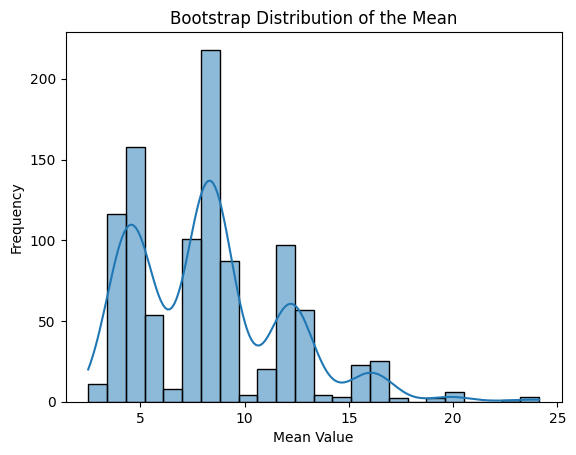

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(boot_means, kde=True)
plt.title("Bootstrap Distribution of the Mean")
plt.xlabel("Mean Value")
plt.ylabel("Frequency")
plt.show()


In [46]:
import pandas as pd

df = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve']
})

sampled_df = df.sample(n=2, random_state=32)
print(sampled_df)


    name
4    Eve
0  Alice


## Creating Pivot Tables with pivot() and pivot_table()

In [48]:
import pandas as pd

data = {
    'Department': ['HR', 'HR', 'IT', 'IT', 'Finance', 'Finance'],
    'Employee': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank'],
    'Salary': [50000, 52000, 60000, 61000, 70000, 72000]
}

df = pd.DataFrame(data)
df



,Department,Employee,Salary
0,HR,Alice,50000
1,HR,Bob,52000
2,IT,Charlie,60000
3,IT,David,61000
4,Finance,Eve,70000
5,Finance,Frank,72000


# Basic Pivot table
Parameters
* data - The dataFrame
* index - Column(s) to group by (rows)
* Columns - Optional: Create sub-columns (like pivoting in Excel)
* Values - What you're summarizing (eg. 'Salary')
* aggfunc - Aggregation function: '**mean**', '**sum**', '**count**', '**min**', '**max**'

In [54]:
pivot = pd.pivot_table(df, values="Salary", index= "Department", aggfunc = "mean")
pivot

,Salary
Department,
Finance,71000.0
HR,51000.0
IT,60500.0


## Pivot with columns

In [59]:
df['Year'] = [2023, 2024, 2023, 2024, 2023, 2024]


pivot = pd.pivot_table(df, values="Salary", index="Department", columns="Year", aggfunc = ["mean", "sum"])
df

,Department,Employee,Salary,Year
0,HR,Alice,50000,2023
1,HR,Bob,52000,2024
2,IT,Charlie,60000,2023
3,IT,David,61000,2024
4,Finance,Eve,70000,2023
5,Finance,Frank,72000,2024
